In [3]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

In [4]:
# Save per-label CSVs
for label, dfs in all_data.items():
    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True)
        combined_df.rename(columns={"vibration": "signal"}, inplace=True)
        out_file = f"Label{label}_{data_structure[label][0]}.csv"
        combined_df.to_csv(out_file, index=False)
        print(f"Exported: {out_file} with shape {combined_df.shape}")
    else:
        print(f"No data to export for label {label}.")

Exported: Label0_Healthy.csv with shape (1280000, 2)
Exported: Label1_OR_Damage.csv with shape (25600, 2)
Exported: Label2_IR_Damage.csv with shape (25600, 2)


In [11]:
# Sampling configuration
interval_length = 290
samples_per_block = 1600

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        segment_list.append(SplitData)

        one_hot = np.zeros((segments, len(DataList)))
        one_hot[:, count] = 1
        one_hot_labels.append(one_hot)

        int_labels = np.full((segments, 1), count)
        integer_labels.append(int_labels)
        
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    # return X, LabelPositional, Label
    return segment_list, one_hot_labels, integer_labels

# Run preparation
X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)




Class: 0 Fault Label: Healthy
Segments: 4407 segments
Sample data (first 5 elements): [-0.10070801  1.22375488 -0.18615723 -0.22277832 -0.1373291 ]

Class: 1 Fault Label: OR_Damage
Segments: 81 segments
Sample data (first 5 elements): [ 0.18005371  0.08850098 -0.05187988 -0.16784668 -0.24414062]

Class: 2 Fault Label: IR_Damage
Segments: 81 segments
Sample data (first 5 elements): [-0.0793457   0.18005371  0.3692627   0.35095215  0.61645508]


In [6]:
def time_train_test_split(segment_list, one_hot_labels, integer_labels, train_ratio=0.8, n_classes=3):
    """
    Perform time-based class-wise train-test split for Paderborn dataset.

    Args:
        segment_list (List[np.ndarray]): List of segment arrays per class.
        one_hot_labels (List[np.ndarray]): One-hot encoded label arrays.
        integer_labels (List[np.ndarray]): Integer label arrays.
        train_ratio (float): Fraction of data for training.
        n_classes (int): Number of classes.

    Returns:
        tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test)
    """
    X_train_list, X_test_list = [], []
    Y_train_list, Y_test_list = [], []
    y_train_list, y_test_list = [], []

    image_shape = (40, 40)

    for class_idx, (segments, one_hot, integer) in enumerate(zip(segment_list, one_hot_labels, integer_labels)):
        n_segments = segments.shape[0]
        train_size = int(n_segments * train_ratio)
        train_segments = segments[:train_size]
        test_segments = segments[train_size:]

        print(f"\nClass {class_idx} (Label {class_idx}):")
        print(f"Train segments: {train_segments.shape[0]}")
        print(f"Test segments: {test_segments.shape[0]}")

        if train_segments.shape[0] > 0:
            X_train_list.append(train_segments)
            Y_train_list.append(one_hot[:train_size])
            y_train_list.append(integer[:train_size])

        if test_segments.shape[0] > 0:
            X_test_list.append(test_segments)
            Y_test_list.append(one_hot[train_size:])
            y_test_list.append(integer[train_size:])

    X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, 1600))
    X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, 1600))
    Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
    Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
    y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
    y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))

    X_2D_train = X_train.reshape([-1, image_shape[0], image_shape[1], 1])
    X_2D_test = X_test.reshape([-1, image_shape[0], image_shape[1], 1])

    print(f"\nFinal X_train shape: {X_2D_train.shape}")
    print(f"Final Y_train shape: {Y_train.shape}")
    print(f"Final y_train shape: {y_train.shape}")
    print(f"Final X_test shape: {X_2D_test.shape}")
    print(f"Final Y_test shape: {Y_test.shape}")
    print(f"Final y_test shape: {y_test.shape}")

    return X_2D_train, X_2D_test, Y_train, Y_test, y_train, y_test


In [12]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

train_ratio = 0.8
n_classes = 3

# Parameters
interval_length = 320
samples_per_block = 1600
n_classes = 3  # Healthy, OR, IR

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_label_train, y_label_test = time_train_test_split(
    X_train, y_train_positional, y_train , train_ratio, n_classes
)

input_shape = (40, 40, 1)   # Reshaped input for CNN 2D
print(f"\nInput Shape: {input_shape}")

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_label_train, return_counts=True)
unique_test, counts_test = np.unique(y_label_test, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_label_train.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_label_test.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split.reshape([-1, 40, 40, 1])
X_2D_test = X_test_split.reshape([-1, 40, 40, 1])

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")



Class 0 (Label 0):
Train segments: 3525
Test segments: 882

Class 1 (Label 1):
Train segments: 64
Test segments: 17

Class 2 (Label 2):
Train segments: 64
Test segments: 17

Final X_train shape: (3653, 40, 40, 1)
Final Y_train shape: (3653, 3)
Final y_train shape: (3653, 1)
Final X_test shape: (916, 40, 40, 1)
Final Y_test shape: (916, 3)
Final y_test shape: (916, 1)

Input Shape: (40, 40, 1)

Class distribution in training set:
Class 0: 3525 samples
Class 1: 64 samples
Class 2: 64 samples

Class distribution in test set:
Class 0: 882 samples
Class 1: 17 samples
Class 2: 17 samples
Train label distribution: [3525   64   64]
Test label distribution: [882  17  17]

X_2D_train shape: (3653, 40, 40, 1)
Y_train shape: (3653, 3)
X_2D_test shape: (916, 40, 40, 1)
Y_test shape: (916, 3)


In [13]:
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=tf.keras.losses.CategoricalCrossentropy(),
                      metrics=['accuracy'])
        return model

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

 Trainable params: 106,083 (414.39 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9381 - loss: 0.1483 - val_accuracy: 0.9644 - val_loss: 0.3040
Epoch 2/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9846 - loss: 0.0318
Epoch 2: val_accuracy did not improve from 0.96443
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9847 - loss: 0.0315 - val_accuracy: 0.9590 - val_loss: 0.2450
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9916 - loss: 0.0165
Epoch 3: val_accuracy did not improve from 0.96443
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9917 - loss: 0.0165 - val_accuracy: 0.8960 - val_loss: 0.3723
Epoch 4/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9959 - loss: 0.0133
Epoch 4: val_accuracy did not improve from 0.96443
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9959 - loss: 0.0133 - val_accuracy: 0.6306 - val_loss: 1.6872
Epoch 5/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9984 - loss: 0.0066
Epoch 5: val_accuracy did not improve f

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9960 - loss: 0.0102 - val_accuracy: 0.9945 - val_loss: 0.0180
Epoch 8/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9986 - loss: 0.0059
Epoch 8: val_accuracy improved from 0.99453 to 0.99726, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_1.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 0.9973 - val_loss: 0.0100
Epoch 9/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9989 - loss: 0.0037
Epoch 9: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9973 - val_loss: 0.0056
Epoch 10/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9984 - loss: 0.0041
Epoch 10: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9984 - loss: 0.0042 - val_accuracy: 0.9932 - val_loss: 0.0330
Epoch 11/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9939 - loss: 0.0171
Epoch 11: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9940 - loss: 0.0169 - val_accuracy: 0.9918 - val_loss: 0.0260
Epoch 12/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9961 - loss: 0.0084
Epoch 12: val_accuracy did not imp

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 3.8539e-04 - val_accuracy: 0.9986 - val_loss: 0.0049
Epoch 21/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9985 - loss: 0.0058
Epoch 21: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 0.9877 - val_loss: 0.0573
Epoch 22/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9985 - loss: 0.0028
Epoch 22: val_accuracy improved from 0.99863 to 1.00000, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_1.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9985 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 23/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 3.3950e-04
Epoch 23: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 3.4492e-04 - val_accuracy: 0.9986 - val_loss: 0.0018
Epoch 24/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 6.9731e-04
Epoch 24: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 6.9284e-04 - val_accuracy: 0.9986 - val_loss: 0.0028
Epoch 25/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.7642e-04
Epoch 25: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 1.7762e-04 - val_accuracy: 0.9959 - val_loss: 0.0135
Epoch 26/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 4.1556e-05
Epoc

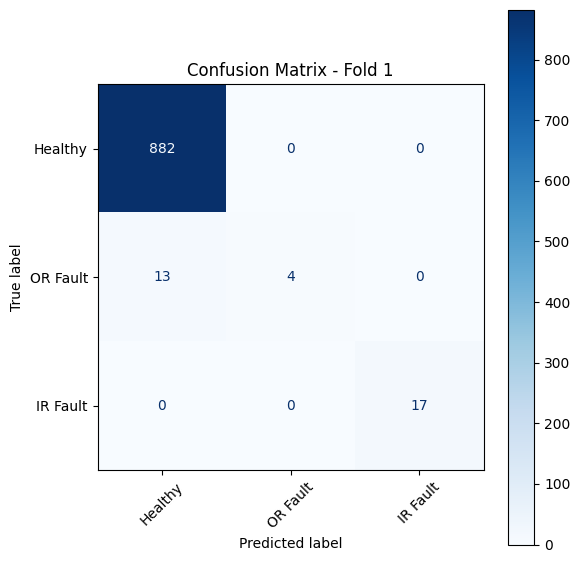

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9945 - val_loss: 0.0128
Epoch 12/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 9.2172e-04
Epoch 12: val_accuracy did not improve from 0.99453
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 9.1509e-04 - val_accuracy: 0.9932 - val_loss: 0.0129
Epoch 13/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 3.3387e-04
Epoch 13: val_accuracy improved from 0.99453 to 0.99590, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_2.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 3.3127e-04 - val_accuracy: 0.9959 - val_loss: 0.0079
Epoch 14/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 1.3813e-04
Epoch 14: val_accuracy improved from 0.99590 to 0.99726, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_2.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 1.0000 - loss: 1.3751e-04 - val_accuracy: 0.9973 - val_loss: 0.0078
Epoch 15/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 1.2005e-04
Epoch 15: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 1.1965e-04 - val_accuracy: 0.9959 - val_loss: 0.0074
Epoch 16/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 1.6327e-04
Epoch 16: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 1.0000 - loss: 1.6456e-04 - val_accuracy: 0.9945 - val_loss: 0.0101
Epoch 17/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 5.4582e-05
Epoch 17: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 5.5019e-05 - val_accuracy: 0.9959 - val_loss: 0.0082
Epoch 18/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 8.9137e-05


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 2.6372e-04 - val_accuracy: 0.9986 - val_loss: 0.0030
Epoch 35/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.9669e-04
Epoch 35: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 1.9506e-04 - val_accuracy: 0.9986 - val_loss: 0.0028
Epoch 36/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 6.7215e-05
Epoch 36: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 6.7202e-05 - val_accuracy: 0.9973 - val_loss: 0.0032
Epoch 37/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.0639e-04
Epoch 37: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 1.0578e-04 - val_accuracy: 0.9973 - val_loss: 0.0031
Epoch 38/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 5.2181e-05


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 1.0000 - loss: 1.1165e-04 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 40/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 7.5951e-05
Epoch 40: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 1.0000 - loss: 7.5489e-05 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 41/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 4.8162e-05
Epoch 41: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 1.0000 - loss: 4.8054e-05 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 42/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 2.2355e-05
Epoch 42: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 2.2280e-05 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 43/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.7883e-04


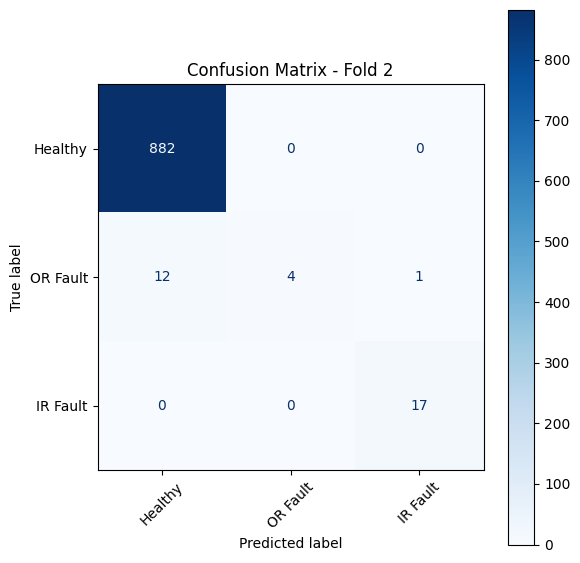

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9352 - loss: 0.1878 - val_accuracy: 0.9644 - val_loss: 0.3840
Epoch 2/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9854 - loss: 0.0325
Epoch 2: val_accuracy did not improve from 0.96443
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9856 - loss: 0.0323 - val_accuracy: 0.8851 - val_loss: 0.4984
Epoch 3/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9937 - loss: 0.0187
Epoch 3: val_accuracy did not improve from 0.96443
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9937 - loss: 0.0187 - val_accuracy: 0.7729 - val_loss: 0.4718
Epoch 4/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9936 - loss: 0.0106
Epoch 4: val_accuracy did not improve from 0.96443
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9936 - loss: 0.0106 - val_accuracy: 0.6881 - val_loss: 1.2825
Epoch 5/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9901 - loss: 0.0151
Epoch 5: val_accuracy did not improve f

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9975 - loss: 0.0064 - val_accuracy: 0.9918 - val_loss: 0.0170
Epoch 8/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9989 - loss: 0.0040
Epoch 8: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9918 - val_loss: 0.0272
Epoch 9/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9985 - loss: 0.0040
Epoch 9: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9986 - loss: 0.0040 - val_accuracy: 0.9850 - val_loss: 0.0368
Epoch 10/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9970 - loss: 0.0062
Epoch 10: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9970 - loss: 0.0063 - val_accuracy: 0.9877 - val_loss: 0.0586
Epoch 11/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9945 - loss: 0.0181
Epoch 11: val_accuracy improved from

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9945 - loss: 0.0178 - val_accuracy: 0.9945 - val_loss: 0.0118
Epoch 12/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9984 - loss: 0.0044
Epoch 12: val_accuracy did not improve from 0.99453
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9984 - loss: 0.0044 - val_accuracy: 0.9932 - val_loss: 0.0133
Epoch 13/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 6.1000e-04
Epoch 13: val_accuracy improved from 0.99453 to 0.99863, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_3.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 6.0505e-04 - val_accuracy: 0.9986 - val_loss: 0.0028
Epoch 14/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 9.3757e-05
Epoch 14: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 9.4960e-05 - val_accuracy: 0.9986 - val_loss: 0.0033
Epoch 15/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.5797e-04
Epoch 15: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 1.5725e-04 - val_accuracy: 0.9986 - val_loss: 0.0038
Epoch 16/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 1.9320e-04
Epoch 16: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 1.0000 - loss: 1.9255e-04 - val_accuracy: 0.9986 - val_loss: 0.0018
Epoch 17/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 9.6949e-05


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 9.5792e-05 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 18/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 5.0846e-05
Epoch 18: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 1.0000 - loss: 5.0400e-05 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 19/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 1.0000 - loss: 2.3519e-05 
Epoch 19: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1018s 11s/step - accuracy: 1.0000 - loss: 2.3506e-05 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 20/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 2.5581e-05
Epoch 20: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 1.0000 - loss: 2.6081e-05 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 21/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 1.0000 - loss: 2.3477e-

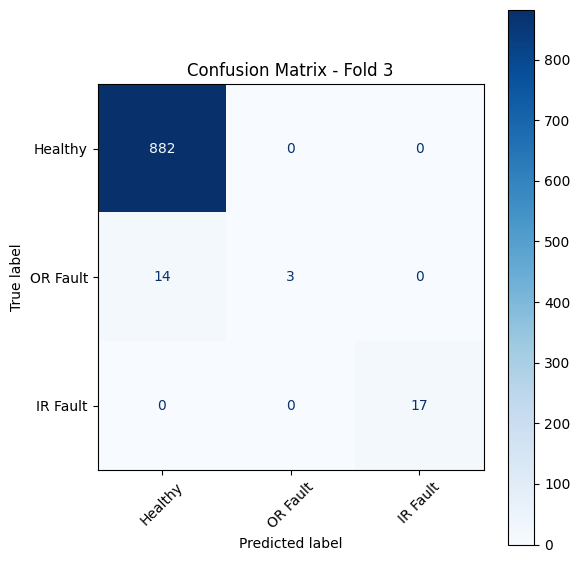

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9947 - loss: 0.0100 - val_accuracy: 0.7151 - val_loss: 0.6958
Epoch 6/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9957 - loss: 0.0115
Epoch 6: val_accuracy improved from 0.71507 to 0.84795, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9957 - loss: 0.0115 - val_accuracy: 0.8479 - val_loss: 0.3917
Epoch 7/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9951 - loss: 0.0131
Epoch 7: val_accuracy improved from 0.84795 to 0.98904, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 314ms/step - accuracy: 0.9951 - loss: 0.0130 - val_accuracy: 0.9890 - val_loss: 0.0492
Epoch 8/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9963 - loss: 0.0067
Epoch 8: val_accuracy did not improve from 0.98904
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9963 - loss: 0.0067 - val_accuracy: 0.9849 - val_loss: 0.0553
Epoch 9/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9994 - loss: 0.0026
Epoch 9: val_accuracy improved from 0.98904 to 0.99863, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9986 - val_loss: 0.0104
Epoch 10/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9999 - loss: 8.6513e-04
Epoch 10: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9999 - loss: 8.9456e-04 - val_accuracy: 0.9973 - val_loss: 0.0087
Epoch 11/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9951 - loss: 0.0134
Epoch 11: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9951 - loss: 0.0135 - val_accuracy: 0.9890 - val_loss: 0.0574
Epoch 12/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9919 - loss: 0.0181
Epoch 12: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9919 - loss: 0.0180 - val_accuracy: 0.9959 - val_loss: 0.0232
Epoch 13/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9969 - loss: 0.0078
Epoch 13: val_accuracy d

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 9.3162e-05 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 20/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 8.4603e-05
Epoch 20: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 8.4143e-05 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 21/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 6.0326e-05
Epoch 21: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 6.0429e-05 - val_accuracy: 1.0000 - val_loss: 9.9521e-04
Epoch 22/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 5.6127e-05
Epoch 22: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 5.7775e-05 - val_accuracy: 1.0000 - val_loss: 5.9212e-04
Epoch 23/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 4.1

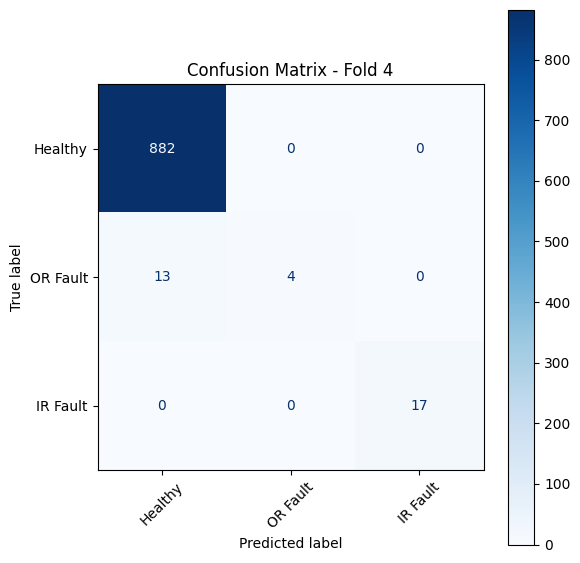

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9956 - loss: 0.0097 - val_accuracy: 0.9740 - val_loss: 0.0847
Epoch 7/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9982 - loss: 0.0087
Epoch 7: val_accuracy improved from 0.97397 to 0.98356, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9983 - loss: 0.0087 - val_accuracy: 0.9836 - val_loss: 0.0373
Epoch 8/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9987 - loss: 0.0045
Epoch 8: val_accuracy improved from 0.98356 to 0.99726, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9973 - val_loss: 0.0096
Epoch 9/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9983 - loss: 0.0079
Epoch 9: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9983 - loss: 0.0079 - val_accuracy: 0.9932 - val_loss: 0.0183
Epoch 10/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9967 - loss: 0.0076
Epoch 10: val_accuracy improved from 0.99726 to 0.99863, saving model to Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9968 - loss: 0.0075 - val_accuracy: 0.9986 - val_loss: 0.0070
Epoch 11/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9981 - loss: 0.0044
Epoch 11: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9981 - loss: 0.0044 - val_accuracy: 0.9767 - val_loss: 0.0570
Epoch 12/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9978 - loss: 0.0065
Epoch 12: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9978 - loss: 0.0065 - val_accuracy: 0.9932 - val_loss: 0.0378
Epoch 13/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9988 - loss: 0.0049
Epoch 13: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9988 - loss: 0.0048 - val_accuracy: 0.9932 - val_loss: 0.0125
Epoch 14/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9984 - loss: 0.0040
Epoch 14: val_accuracy did not i

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 2.5534e-05 - val_accuracy: 1.0000 - val_loss: 9.9804e-04
Epoch 29/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 8.2863e-05
Epoch 29: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 8.2060e-05 - val_accuracy: 1.0000 - val_loss: 3.6476e-04
Epoch 30/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 3.0863e-05
Epoch 30: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 3.0823e-05 - val_accuracy: 1.0000 - val_loss: 4.4635e-04
Epoch 31/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 6.9562e-05
Epoch 31: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 6.8405e-05 - val_accuracy: 1.0000 - val_loss: 5.0495e-04
Epoch 32/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - l

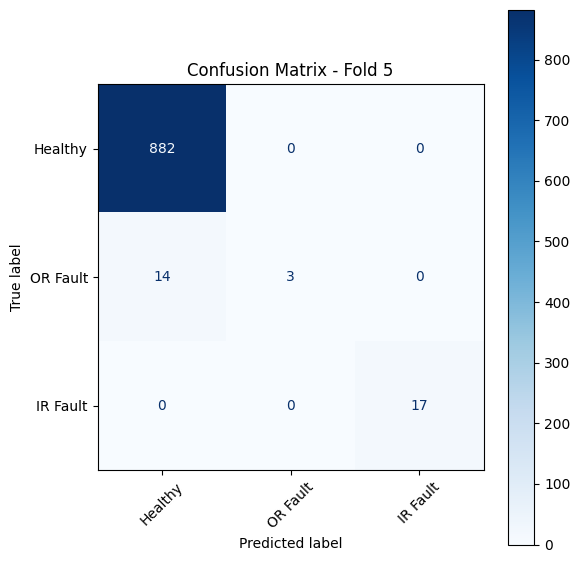

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 14860.99 seconds (247.68 minutes)


In [14]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

foldername = "Paderborn_results/Paderborn-imbalance-2D-Time-Train-Test-Split/"

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [15]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 100.00%
Test Accuracy: 98.54%
Train Precision: 100.00%
Test Precision: 98.56%
Train Recall: 100.00%
Test Recall: 98.54%
Train F1: 100.00%
Test F1: 98.07%
Train Log Loss: 0.0004
Test Log Loss: 0.1868
Train Balanced Accuracy: 100.00%
Test Balanced Accuracy: 73.73%
Train Precision (Macro): 100.00%
Train Recall (Macro): 100.00%
Train F1 Score (Macro): 100.00%
Test Precision (Macro): 99.14%
Test Recall (Macro): 73.73%
Test F1 Score (Macro): 77.85%


115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


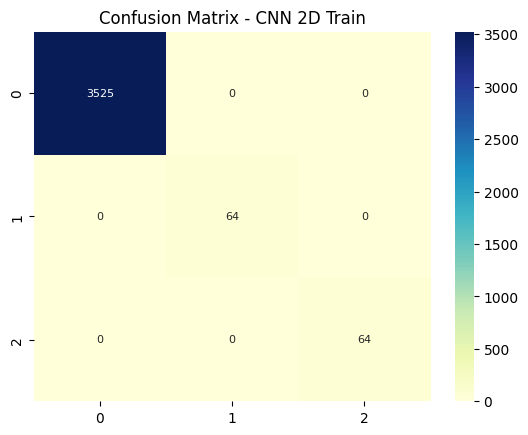

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


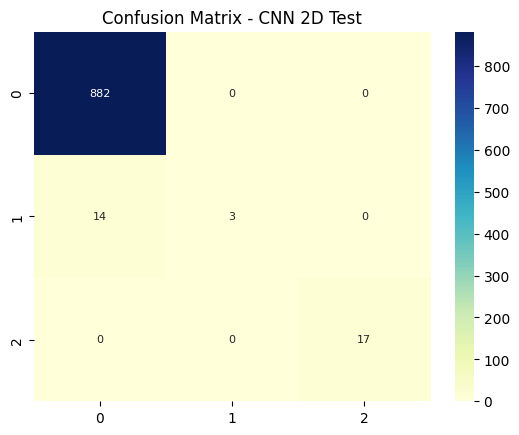

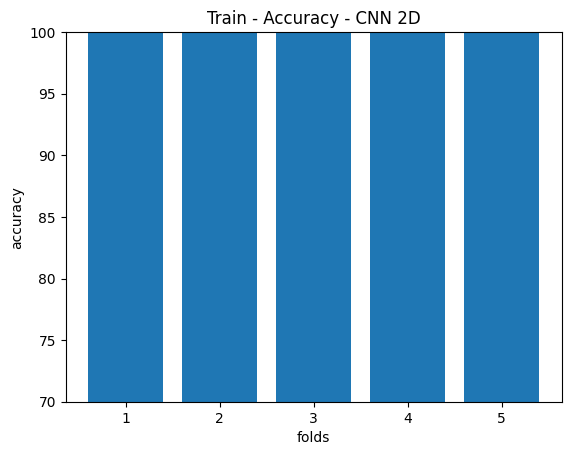

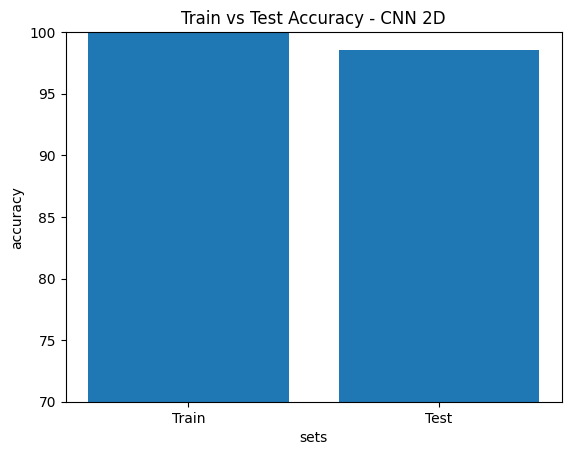

In [16]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()
